In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nflreadpy as nfl
from IPython.display import display
import requests
from io import StringIO
import time
import os

In [952]:
draft_url = "https://github.com/nflverse/nflverse-data/releases/download/draft_picks/draft_picks.csv"
draft = pd.read_csv(draft_url)

In [953]:
# Strict Groupings

DB = ['CB', 'DB', 'FS', 'LCB', 'RCB', 'S', 'SS']
DL = ['DE', 'DL', 'DT', 'EDGE', 'LDE', 'LDT', 'NT', 'RDE', 'RDT']
OLB = ['LOLB', 'OLB', 'ROLB']
LB = ['ILB', 'LB', 'LILB', 'LLB', 'MLB', 'RILB', 'RLB']

ST = ['K', 'LS', 'P', 'PR'] 

OL = ['C', 'G','G/C', 'G/T', 'LG', 'LT', 'OG', 'OL', 'OT', 'RG', 'RT', 'T']
H = ['TE', 'FB']
RB = ['RB']
WR = ['WR']
QB = ['QB'] 

strict_map = {}

for pos in DB:
    strict_map[pos] = "DB"
for pos in DL:
    strict_map[pos] = "DL"
for pos in OLB:
    strict_map[pos] = "OLB"
for pos in LB:
    strict_map[pos] = "LB"
for pos in ST:
    strict_map[pos] = "ST"
for pos in OL:
    strict_map[pos] = "OL"
for pos in H:
    strict_map[pos] = "TE"
for pos in RB:
    strict_map[pos] = "RB"
for pos in WR:
    strict_map[pos] = "WR"
for pos in QB:
    strict_map[pos] = "QB"

In [954]:
draft = draft[(draft["season"] >= 2000) & (draft["season"] <= 2020)]
draft = draft[draft['w_av'].notna()]

position_order = ['DB', 'DL', 'LB', 'OLB', 'OL', 'QB', 'RB', 'WR', 'TE', 'ST']

draft["strict_grouping"] = draft["position"].map(strict_map)

expected = pd.DataFrame(draft.groupby("pick")["w_av"].mean().reset_index().rename(columns={"w_av": "expected_w_av"}))

expected = expected.sort_values('pick')

expected['expected_w_av_smooth'] = expected['expected_w_av'].rolling(window=15, center=True, min_periods=1).mean()

draft = draft.merge(expected[['pick', 'expected_w_av_smooth']], on='pick')

draft['ev_delta'] = draft['w_av'] - draft['expected_w_av_smooth']
draft['ev_ratio'] = draft['w_av'] / draft['expected_w_av_smooth']

expected = expected.set_index('pick')

pos_counts = pd.DataFrame(draft['strict_grouping'].value_counts())
pos_counts = pos_counts.reindex(position_order)

pos_avg_dr_av = pd.DataFrame(draft.groupby('strict_grouping')['dr_av'].mean())
pos_avg_dr_av = pos_avg_dr_av.reindex(position_order)

pos_w_av = pd.DataFrame(draft.groupby('strict_grouping')['w_av'].mean())
pos_w_av = pos_w_av.reindex(position_order)

pos_ev_delta = pd.DataFrame(draft.groupby('strict_grouping')['ev_delta'].mean())
pos_ev_delta = pos_ev_delta.reindex(position_order)

pos_ratio = pd.DataFrame(draft.groupby('strict_grouping')['ev_ratio'].mean())
pos_ratio = pos_ratio.reindex(position_order)

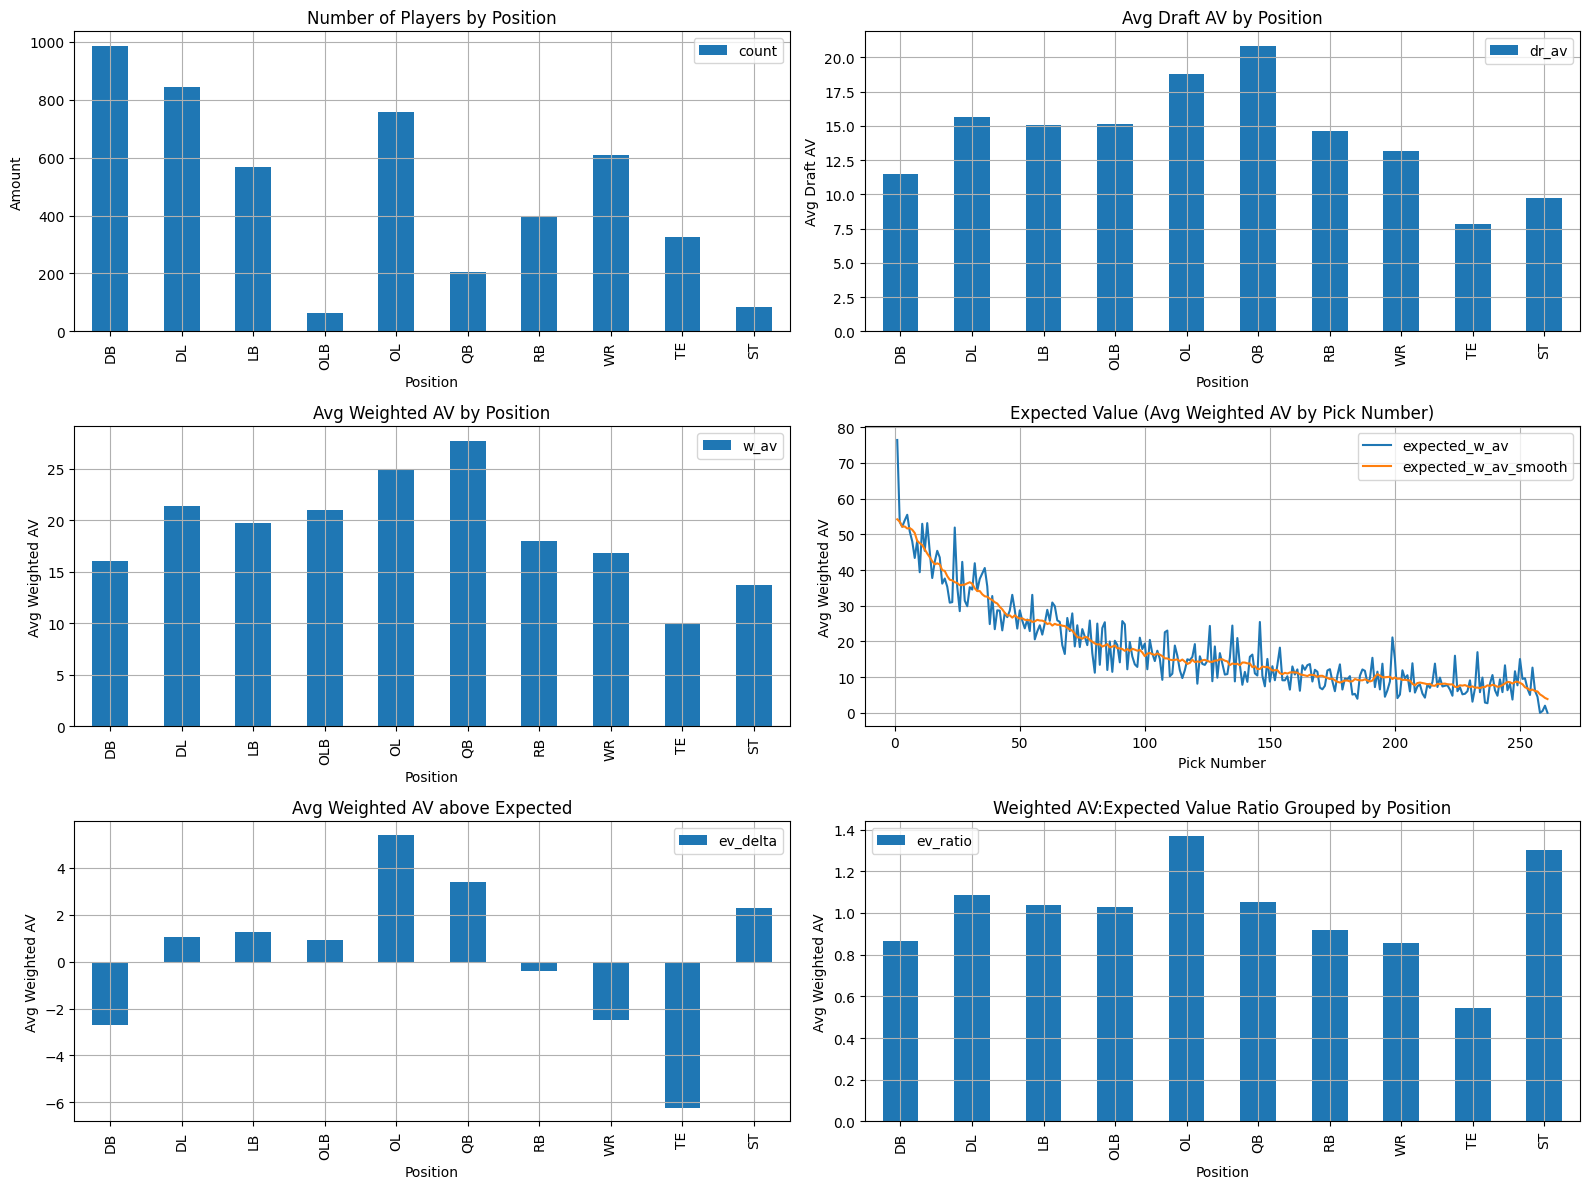

In [955]:

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

pos_counts.plot.bar(
    ax=axes[0, 0],
    title='Number of Players by Position',
    xlabel='Position',
    ylabel='Amount',
    grid=True,
)

pos_avg_dr_av.plot.bar(
    ax=axes[0, 1],
    title='Avg Draft AV by Position',
    xlabel='Position',
    ylabel='Avg Draft AV',
    grid=True,
)

pos_w_av.plot.bar(
    ax=axes[1, 0],
    title='Avg Weighted AV by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

expected.plot.line(
    ax=axes[1, 1],
    title='Expected Value (Avg Weighted AV by Pick Number)',
    xlabel='Pick Number',
    ylabel='Avg Weighted AV',
    grid=True,
)

pos_ev_delta.plot.bar(
    ax=axes[2, 0],
    title='Avg Weighted AV above Expected',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

pos_ratio.plot.bar(
    ax=axes[2, 1],
    title='Weighted AV:Expected Value Ratio Grouped by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

plt.tight_layout()
plt.show()

In [956]:
pos_ratio.to_pickle("draft_pos_ev_ratio.pkl")

In [816]:
players_url = "https://github.com/nflverse/nflverse-data/releases/download/players/players.csv"
players = pd.read_csv(players_url)
contracts = pd.read_parquet(
    "historical_contracts.parquet",
    engine="fastparquet"
)

contracts = pd.DataFrame(contracts.loc[contracts['year_signed'] >= 2017])

games = pd.read_csv('games (1).csv')
pfr_roster = pd.read_csv('pfr_rosters.csv')

C:\Users\SHANE\AppData\Local\Temp\ipykernel_16692\1972006020.py:11: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  pfr_roster = pd.read_csv('pfr_rosters.csv')


In [817]:
games = pd.DataFrame(games.loc[games['season'] >= 2002])

games = games.drop(columns=['away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'gameday', 'weekday',
       'gametime'])



games['home_win'] = (games['result'] > 0).astype(int)
games['away_loss'] = (games['result'] > 0).astype(int)
games['home_loss'] = (games['result'] < 0).astype(int)
games['away_win'] = (games['result'] < 0).astype(int)
games['home_tie'] = (games['result'] == 0).astype(int)
games['away_tie'] = (games['result'] == 0).astype(int)

games['home_pd'] = games['home_score'] - games['away_score']
games['away_pd'] = games['away_score'] - games['home_score']

home_pd = games.groupby(['season', 'home_team'])['home_pd'].sum().reset_index()
home_pd = home_pd.rename(columns={'home_team': 'team'})
away_pd = games.groupby(['season', 'away_team'])['away_pd'].sum().reset_index()
away_pd = away_pd.rename(columns={'away_team': 'team'})

home_wins = pd.DataFrame()
home_wins = games.groupby(['season', 'home_team'])['home_win'].sum().reset_index()
home_wins = home_wins.rename(columns={'home_team': 'team'})

away_wins = pd.DataFrame()
away_wins = games.groupby(['season', 'away_team'])['away_win'].sum().reset_index()
away_wins = away_wins.rename(columns={'away_team': 'team'})

home_loss = pd.DataFrame()
home_loss = games.groupby(['season', 'home_team'])['home_loss'].sum().reset_index()
home_loss = home_loss.rename(columns={'home_team': 'team'})

away_loss = pd.DataFrame()
away_loss = games.groupby(['season', 'away_team'])['away_loss'].sum().reset_index()
away_loss = away_loss.rename(columns={'away_team': 'team'})

ties_home = games.groupby(['season', 'home_team'])['home_tie'].sum().reset_index()
ties_home = ties_home.rename(columns={'home_team': 'team'})

ties_away = games.groupby(['season', 'away_team'])['away_tie'].sum().reset_index()
ties_away = ties_away.rename(columns={'away_team': 'team'})



In [818]:
seasons = pd.DataFrame()

seasons_win = pd.merge(home_wins, away_wins, on=['season', 'team'])
seasons_loss = pd.merge(home_loss, away_loss, on=['season', 'team'])
seasons_tie = pd.merge(ties_home, ties_away, on=['season', 'team'])
seasons_pd = pd.merge(home_pd, away_pd, on=['season', 'team'])

seasons_wl = pd.merge(seasons_win, seasons_loss, on=['season', 'team'])
seasons_wlt = pd.merge(seasons_wl, seasons_tie, on=['season', 'team'])
seasons = pd.merge(seasons_wlt, seasons_pd, on=['season', 'team'])

seasons['wins'] = seasons['home_win'] + seasons['away_win']
seasons['loss'] = seasons['home_loss'] + seasons['away_loss']
seasons['tie'] = seasons['home_tie'] + seasons['away_tie']
seasons['point_diff'] = seasons['home_pd'] + seasons['away_pd']
seasons['record'] = (
    seasons['wins'].astype(str) + '-' +
    seasons['loss'].astype(str) + '-' +
    seasons['tie'].astype(str)
)

seasons['games'] = seasons['tie'] + seasons['wins'] + seasons['loss']
seasons['playoffs'] = -1
seasons['win%'] = seasons['wins'] / seasons['games']

seasons.loc[(seasons['games'] > 16) & (seasons['season'] < 2021), 'playoffs'] = 1
seasons.loc[seasons['games'] > 17, 'playoffs'] = 1
seasons.loc[seasons['games'] == 16, 'playoffs'] = 0
seasons.loc[(seasons['games'] == 17) & (seasons['season'] >= 2021), 'playoffs'] = 0

seasons.loc[seasons['team'] == 'OAK', 'team'] = 'LV'
seasons.loc[seasons['team'] == 'SD', 'team'] = 'LAC'
seasons.loc[seasons['team'] == 'STL', 'team'] = 'LA'

In [819]:
contracts['player_clean'] = contracts['player'].str.lower().str.strip()
pfr_roster['player_clean'] = pfr_roster['player'].str.lower().str.strip()

contracts_filt = contracts[
    (contracts['year_signed'] >= 2017) & 
    (contracts['year_signed'] <= 2025)
].copy()

contracts_mapped = contracts_filt.merge(
    players[['gsis_id', 'pfr_id']],
    on='gsis_id',
    how='left'
)

contracts_ids = contracts_mapped['pfr_id'].dropna().unique()
roster_ids = pfr_roster['pfr_player_id'].dropna().unique()

common_ids = set(contracts_ids).intersection(set(roster_ids))

print("Contracts unique players:", len(contracts_ids))
print("Roster unique players:", len(roster_ids))
print("Overlap:", len(common_ids))

Contracts unique players: 6773
Roster unique players: 9992
Overlap: 4386


In [820]:
pfr_roster = pfr_roster[pfr_roster["av"] > 0]
pfr_roster.loc[pfr_roster['player'] == 'Beau Brinkley', 'pos'] = 'LS'
pfr_roster.loc[pfr_roster['player'] == 'Logan Thomas', 'pos'] = 'TE'
pfr_roster.loc[pfr_roster['player'] == 'Oliver Hoyte', 'pos'] = 'RB'
pfr_roster.loc[pfr_roster['pos'] == 'G,C', 'pos'] = 'G/C'
pfr_roster.loc[pfr_roster['pos'] == 'C,G', 'pos'] = 'G/C'
pfr_roster.loc[pfr_roster['pos'] == 'G,T', 'pos'] = 'G/T'
pfr_roster.loc[(pfr_roster['player'] == 'Lorenzo Alexander') & (pfr_roster['season'] < 2010), 'pos'] = 'DT'
pfr_roster.loc[(pfr_roster['player'] == 'Lorenzo Alexander') & (pfr_roster['season'] >= 2010), 'pos'] = 'LB'
pfr_roster.loc[(pfr_roster['player'] == 'Ty Montgomery') & (pfr_roster['season'] < 2016), 'pos'] = 'WR'
pfr_roster.loc[(pfr_roster['player'] == 'Ty Montgomery') & (pfr_roster['season'] >= 2016), 'pos'] = 'RB'
pfr_roster.loc[(pfr_roster['player'] == 'Jamal Agnew') & (pfr_roster['season'] < 2020), 'pos'] = 'CB'
pfr_roster.loc[(pfr_roster['player'] == 'Jamal Agnew') & (pfr_roster['season'] >= 2020), 'pos'] = 'WR'

In [893]:
folder = "Roster Data"
dfs = []

for file in os.listdir(folder):
    if file.endswith(".txt"):
        path = os.path.join(folder, file)

        name = file.replace(".txt", "")
        team, season = name.split("_")
        season = int(season)
        
        df = pd.read_csv(path)
        
        df = df[df["Player"] != "Team Total"]
        
        df = df.drop(columns=["Player-additional"], errors="ignore")
        
        df = df.rename(columns={
            "No.": "no",
            "Player": "player",
            "Age": "age",
            "Pos": "pos",
            "G": "g",
            "GS": "gs",
            "Wt": "wt",
            "Ht": "ht",
            "College/Univ": "college_univ",
            "BirthDate": "birth_date",
            "Yrs": "yrs",
            "AV": "av",
            "Drafted (tm/rnd/yr)": "drafted_tm_rnd_yr"
        })
        
        df["pfr"] = team
        df['nfl'] = team
        df["season"] = season
        
        df["pfr_player_id"] = None
        df["salary"] = None
        
        df = df[
            ['season', 'pfr', 'nfl', 'pfr_player_id', 'no', 'player', 'age', 'pos',
             'g', 'gs', 'wt', 'ht', 'college_univ', 'birth_date',
             'yrs', 'av', 'drafted_tm_rnd_yr', 'salary']
        ]
        
        dfs.append(df)

pfr_new = pd.concat(dfs, ignore_index=True)

print(pfr_new.shape)

(4541, 18)


In [903]:
set(pfr_roster.columns) - set(pfr_new.columns)
set(pfr_new.columns) - set(pfr_roster.columns)

set()

In [904]:
for col in pfr_roster.columns:
    if col not in pfr_new.columns:
        pfr_new[col] = None

In [905]:
pfr_new = pfr_new[pfr_roster.columns]

In [906]:
pfr_all = pd.concat([pfr_roster, pfr_new], ignore_index=True)

pfr_all.loc[pfr_all['player'] == 'Calvin Throckmorton', 'pos'] = 'G'
pfr_all.loc[pfr_all['player'] == 'Geno Stone', 'pos'] = 'S'
pfr_all.loc[pfr_all['player'] == 'Sebastian Joseph-Day', 'pos'] = 'DE'
pfr_all.loc[(pfr_all['player'] == 'Sione Takitaki') & (pfr_all['season'] == 2023), 'pos'] = 'LB'

#Taysom Hill splitting of AV into a TE entry and a QB entry since spent similar snap counts at both positions
mask = (pfr_all["player"] == "Taysom Hill") & (pfr_all["pos"] == "TE/QB")
dual_rows = pfr_all[mask].copy()
te_rows = dual_rows.copy()
te_rows["pos"] = "TE"
te_rows["av"] = te_rows["av"] / 2
qb_rows = dual_rows.copy()
qb_rows["pos"] = "QB"
qb_rows["av"] = qb_rows["av"] / 2
pfr_all = pfr_all[~mask]
pfr_all = pd.concat([pfr_all, te_rows, qb_rows], ignore_index=True)

#Scott Matlock splitting of AV into a FB entry and a DL entry since spent similar snap counts at both positions
mask = (pfr_all["player"] == "Scott Matlock") & (pfr_all["pos"] == "FB/DL")
dual_rows = pfr_all[mask].copy()
FB_rows = dual_rows.copy()
FB_rows["pos"] = "FB"
FB_rows["av"] = FB_rows["av"] * .75
DL_rows = dual_rows.copy()
DL_rows["pos"] = "DL"
DL_rows["av"] = DL_rows["av"] * .25
pfr_all = pfr_all[~mask]
pfr_all = pd.concat([pfr_all, te_rows, qb_rows], ignore_index=True)


In [914]:
# Strict Groupings

DB = ['CB', 'DB', 'FS', 'LCB', 'RCB', 'S', 'SS']
DL = ['DE', 'DL', 'DT', 'EDGE', 'LDE', 'LDT', 'NT', 'RDE', 'RDT']
OLB = ['LOLB', 'OLB', 'ROLB']
LB = ['ILB', 'LB', 'LILB', 'LLB', 'MLB', 'RILB', 'RLB']

ST = ['K', 'LS', 'P', 'PR'] 

OL = ['C', 'G','G/C', 'G/T', 'LG', 'LT', 'OG', 'OL', 'OT', 'RG', 'RT', 'T']
H = ['TE', 'FB']
RB = ['RB']
WR = ['WR']
QB = ['QB'] 

pfr_all['strict_grouping'] = -1

strict_map = {}

for pos in DB:
    strict_map[pos] = "DB"
for pos in DL:
    strict_map[pos] = "DL"
for pos in OLB:
    strict_map[pos] = "OLB"
for pos in LB:
    strict_map[pos] = "LB"
for pos in ST:
    strict_map[pos] = "ST"
for pos in OL:
    strict_map[pos] = "OL"
for pos in H:
    strict_map[pos] = "TE"
for pos in RB:
    strict_map[pos] = "RB"
for pos in WR:
    strict_map[pos] = "WR"
for pos in QB:
    strict_map[pos] = "QB"

pfr_all['strict_grouping'] = pfr_all["pos"].map(strict_map)

In [915]:
# Fractional Groupings
# D - DL, LB, DB
# O - QB, OL/TE/FB, RB/WR

DB = ['CB', 'DB', 'FS', 'LCB', 'RCB', 'S', 'SS']
DL = ['DE', 'DL', 'DT', 'EDGE', 'LDE', 'LDT', 'NT', 'RDE', 'RDT']
LB = ['LOLB', 'OLB', 'ROLB','ILB', 'LB', 'LILB', 'LLB', 'MLB', 'RILB', 'RLB']

ST = ['K', 'LS', 'P', 'PR'] 

OL = ['C', 'G','G/C', 'G/T', 'LG', 'LT', 'OG', 'OL', 'OT', 'RG', 'RT', 'T', 'TE', 'FB']
SKILL = ['RB', 'WR']
QB = ['QB']

pfr_all['fractional_grouping'] = -1

fractional_map = {}

for pos in DB:
    fractional_map[pos] = "DB"
for pos in DL:
    fractional_map[pos] = "DL"
for pos in LB:
    fractional_map[pos] = "LB"
for pos in ST:
    fractional_map[pos] = "ST"
for pos in OL:
    fractional_map[pos] = "OL"
for pos in SKILL:
    fractional_map[pos] = "SKILL"
for pos in QB:
    fractional_map[pos] = "QB"

pfr_all["fractional_grouping"] = pfr_all["pos"].map(fractional_map)

In [916]:
# Most General Groupings
# D - Front, Secondary
# O - Big, Skill

SECONDARY = ['CB', 'DB', 'FS', 'LCB', 'RCB', 'S', 'SS', 'ILB', 'LB', 'LILB', 'LLB', 'MLB', 'RILB', 'RLB']
FRONT = ['DE', 'DL', 'DT', 'EDGE', 'LDE', 'LDT', 'NT', 'RDE', 'RDT', 'LOLB', 'OLB', 'ROLB']

ST = ['K', 'LS', 'P', 'PR'] 

BIG = ['C', 'G','G/C', 'G/T', 'LG', 'LT', 'OG', 'OL', 'OT', 'RG', 'RT', 'T', 'TE', 'FB']
SKILL = ['RB', 'WR', 'QB']  

pfr_all['general_grouping'] = -1

general_map = {}

for pos in SECONDARY:
    general_map[pos] = "SECONDARY"
for pos in FRONT:
    general_map[pos] = "FRONT"
for pos in ST:
    general_map[pos] = "ST"
for pos in BIG:
    general_map[pos] = "BIG"
for pos in SKILL:
    general_map[pos] = "SKILL"

pfr_all["general_grouping"] = pfr_all["pos"].map(general_map)    

In [917]:
def compare_teams(df, team1, team2):
    df1 = df[df["nfl"] == team1].copy()
    df2 = df[df["nfl"] == team2].copy()
    
    # Keep only relevant columns for comparison
    cols = cols = ["player", "season", "pos", "g", "gs", "av"] # add more if you want stricter check
    
    df1 = df1[cols].sort_values(cols).reset_index(drop=True)
    df2 = df2[cols].sort_values(cols).reset_index(drop=True)
    
    print(f"{team1} rows:", len(df1))
    print(f"{team2} rows:", len(df2))
    
    # Check equality
    equal = df1.equals(df2)
    
    print("Are identical:", equal)
    
    if not equal:
        # Show differences
        diff1 = df1.merge(df2, on=cols, how="left", indicator=True)
        diff2 = df2.merge(df1, on=cols, how="left", indicator=True)
        
        print("\nRows in", team1, "not in", team2)
        print(diff1[diff1["_merge"] == "left_only"].head())
        
        print("\nRows in", team2, "not in", team1)
        print(diff2[diff2["_merge"] == "left_only"].head())
    
    return equal

In [918]:
pfr_all = pfr_all[~pfr_all["nfl"].isin(["JAC", "OAK", "SD", "STL"])]

In [919]:
pfr_all = pfr_all.merge(seasons, left_on=['nfl', 'season'], right_on=['team', 'season'], how='left')

In [934]:
av = pfr_all.copy()
av_full = av.copy()

av = av[['season', 'nfl', 'pfr_player_id', 'no', 'player', 'age', 'pos',
    'g', 'gs', 'yrs', 'av',
    'drafted_tm_rnd_yr', 'salary', 'player_clean', 'strict_grouping',
    'fractional_grouping', 'general_grouping', 'team', 'home_win',
    'away_win', 'home_loss', 'away_loss', 'home_tie', 'away_tie', 'home_pd',
    'away_pd', 'wins', 'loss', 'tie', 'point_diff', 'record', 'games',
    'playoffs', 'win%']]

av_playoffs = av.loc[av['playoffs'] == 1]

av_playoffs_strict = pd.DataFrame(av_playoffs.groupby(['season', 'nfl', 'strict_grouping'])['av'].sum().reset_index())
av_team_strict_wide = (
    av_playoffs_strict
    .pivot(index=["season", "nfl"], columns="strict_grouping", values="av")
    .reset_index()
)

av_playoffs_fractional = pd.DataFrame(av_playoffs.groupby(['season', 'nfl', 'fractional_grouping'])['av'].sum().reset_index())
av_team_fractional_wide = (
    av_playoffs_fractional
    .pivot(index=['season', 'nfl'], columns="fractional_grouping", values="av")
    .reset_index()
)

av_playoffs_general = pd.DataFrame(av_playoffs.groupby(['season', 'nfl', 'general_grouping'])['av'].sum().reset_index())

av_team_general_wide = (
    av_playoffs_general
    .pivot(index=['season', 'nfl'], columns="general_grouping", values="av")
    .reset_index()
)


strict_baseline = (
av_team_strict_wide
.drop(columns=["season", "nfl"])
.mean()
.sort_values(ascending=False)
)
print(strict_baseline)

fractional_baseline = (
    av_team_fractional_wide
    .drop(columns=["season", "nfl"])
    .mean()
)
print(fractional_baseline)

general_baseline = (
    av_team_general_wide
    .drop(columns=["season", "nfl"])
    .mean()
)
print(general_baseline)


av_pct_strict = av_team_strict_wide.copy()
pos_cols = av_pct_strict.columns.drop(["season", "nfl"])
av_pct_strict[pos_cols] = av_pct_strict[pos_cols].div(
    av_pct_strict[pos_cols].sum(axis=1), axis=0
)
av_pct_strict_baseline = av_pct_strict[pos_cols].mean()
print(av_pct_strict_baseline)

av_pct_fractional = av_team_fractional_wide.copy()
pos_cols = av_pct_fractional.columns.drop(["season", "nfl"])
av_pct_fractional[pos_cols] = av_pct_fractional[pos_cols].div(
    av_pct_fractional[pos_cols].sum(axis=1), axis=0
)
av_pct_fractional_baseline = av_pct_fractional[pos_cols].mean()
print(av_pct_fractional_baseline)

av_pct_general = av_team_general_wide.copy()
pos_cols = av_pct_general.columns.drop(["season", "nfl"])
av_pct_general[pos_cols] = av_pct_general[pos_cols].div(
    av_pct_general[pos_cols].sum(axis=1), axis=0
)
av_pct_general_baseline = av_pct_general[pos_cols].mean()
print(av_pct_general_baseline)


# Strict
team_data = av_team_strict_wide.merge(
    av_full[["season","nfl","wins","win%","playoffs"]].drop_duplicates(),
    on=["season","nfl"],
    how="left"
)

pos_cols = team_data.columns.drop(["season","nfl","wins","win%","playoffs"])

playoff_corr_with_wins = team_data[pos_cols].corrwith(team_data["wins"]).sort_values(ascending=False)

print(playoff_corr_with_wins)
playoff_corr_with_winpct = team_data[pos_cols].corrwith(team_data["win%"]).sort_values(ascending=False)

print(playoff_corr_with_winpct)
playoff_means_strict = team_data[pos_cols].mean()
print("__________________")
print("Playoff Means Strict Grouping")
print(playoff_means_strict)
print("__________________")

# Fractional
team_data = av_team_fractional_wide.merge(
    av_full[["season","nfl","wins","win%","playoffs"]].drop_duplicates(),
    on=["season","nfl"],
    how="left"
)

pos_cols = team_data.columns.drop(["season","nfl","wins","win%","playoffs"])

playoff_corr_with_wins = team_data[pos_cols].corrwith(team_data["wins"]).sort_values(ascending=False)

print(playoff_corr_with_wins)
playoff_corr_with_winpct = team_data[pos_cols].corrwith(team_data["win%"]).sort_values(ascending=False)

print(playoff_corr_with_winpct)
playoff_means_fractional = team_data[pos_cols].mean()
print("__________________")
print("Playoff Means Fractional Grouping")
print(playoff_means_fractional)
print("__________________")

# General
team_data = av_team_general_wide.merge(
    av_full[["season","nfl","wins","win%","playoffs"]].drop_duplicates(),
    on=["season","nfl"],
    how="left"
)

pos_cols = team_data.columns.drop(["season","nfl","wins","win%","playoffs"])

playoff_corr_with_wins = team_data[pos_cols].corrwith(team_data["wins"]).sort_values(ascending=False)

print(playoff_corr_with_wins)
playoff_corr_with_winpct = team_data[pos_cols].corrwith(team_data["win%"]).sort_values(ascending=False)

print(playoff_corr_with_winpct)
playoff_means_general = team_data[pos_cols].mean()
print("__________________")
print("Playoff Means General Grouping")
print(playoff_means_general)
print("__________________")


strict_grouping
OL     49.955882
DL     39.900735
DB     37.650735
WR     25.838235
LB     24.941176
RB     17.503676
QB     14.970588
OLB    10.645714
TE      8.426471
ST      6.018382
dtype: float64
fractional_grouping
DB       37.650735
DL       39.900735
LB       31.790441
OL       58.382353
QB       14.970588
SKILL    43.341912
ST        6.018382
dtype: float64
general_grouping
BIG          58.382353
FRONT        46.750000
SECONDARY    62.591912
SKILL        58.312500
ST            6.018382
dtype: float64
strict_grouping
DB     0.162442
DL     0.172589
LB     0.107223
OL     0.214852
OLB    0.046255
QB     0.064339
RB     0.075203
ST     0.026065
TE     0.036089
WR     0.111437
dtype: float64
fractional_grouping
DB       0.162442
DL       0.172589
LB       0.136983
OL       0.250941
QB       0.064339
SKILL    0.186640
ST       0.026065
dtype: float64
general_grouping
BIG          0.250941
FRONT        0.202349
SECONDARY    0.269665
SKILL        0.250979
ST           0.026065
dtype

In [935]:
av = pfr_all.copy()

av = av[['season', 'nfl', 'pfr_player_id', 'no', 'player', 'age', 'pos',
    'g', 'gs', 'yrs', 'av',
    'drafted_tm_rnd_yr', 'salary', 'player_clean', 'strict_grouping',
    'fractional_grouping', 'general_grouping', 'team', 'home_win',
    'away_win', 'home_loss', 'away_loss', 'home_tie', 'away_tie', 'home_pd',
    'away_pd', 'wins', 'loss', 'tie', 'point_diff', 'record', 'games',
    'playoffs', 'win%']]

av_reg = av.loc[av['playoffs'] == 0]

av_reg_strict = pd.DataFrame(av_reg.groupby(['season', 'nfl', 'strict_grouping'])['av'].sum().reset_index())
av_team_strict_wide = (
    av_reg_strict
    .pivot(index=["season", "nfl"], columns="strict_grouping", values="av")
    .reset_index()
)

av_reg_fractional = pd.DataFrame(av_reg.groupby(['season', 'nfl', 'fractional_grouping'])['av'].sum().reset_index())
av_team_fractional_wide = (
    av_reg_fractional
    .pivot(index=['season', 'nfl'], columns="fractional_grouping", values="av")
    .reset_index()
)

av_reg_general = pd.DataFrame(av_reg.groupby(['season', 'nfl', 'general_grouping'])['av'].sum().reset_index())

av_team_general_wide = (
    av_reg_general
    .pivot(index=['season', 'nfl'], columns="general_grouping", values="av")
    .reset_index()
)


strict_baseline = (
av_team_strict_wide
.drop(columns=["season", "nfl"])
.mean()
.sort_values(ascending=False)
)
print(strict_baseline)

fractional_baseline = (
    av_team_fractional_wide
    .drop(columns=["season", "nfl"])
    .mean()
)
print(fractional_baseline)

general_baseline = (
    av_team_general_wide
    .drop(columns=["season", "nfl"])
    .mean()
)
print(general_baseline)


av_pct_strict = av_team_strict_wide.copy()
pos_cols = av_pct_strict.columns.drop(["season", "nfl"])
av_pct_strict[pos_cols] = av_pct_strict[pos_cols].div(
    av_pct_strict[pos_cols].sum(axis=1), axis=0
)
av_pct_strict_baseline = av_pct_strict[pos_cols].mean()
print(av_pct_strict_baseline)

av_pct_fractional = av_team_fractional_wide.copy()
pos_cols = av_pct_fractional.columns.drop(["season", "nfl"])
av_pct_fractional[pos_cols] = av_pct_fractional[pos_cols].div(
    av_pct_fractional[pos_cols].sum(axis=1), axis=0
)
av_pct_fractional_baseline = av_pct_fractional[pos_cols].mean()
print(av_pct_fractional_baseline)

av_pct_general = av_team_general_wide.copy()
pos_cols = av_pct_general.columns.drop(["season", "nfl"])
av_pct_general[pos_cols] = av_pct_general[pos_cols].div(
    av_pct_general[pos_cols].sum(axis=1), axis=0
)
av_pct_general_baseline = av_pct_general[pos_cols].mean()
print(av_pct_general_baseline)



# Strict
team_data = av_team_strict_wide.merge(
    av_full[["season","nfl","wins","win%","playoffs"]].drop_duplicates(),
    on=["season","nfl"],
    how="left"
)

pos_cols = team_data.columns.drop(["season","nfl","wins","win%","playoffs"])

corr_with_wins = team_data[pos_cols].corrwith(team_data["wins"]).sort_values(ascending=False)

print(corr_with_wins)
corr_with_winpct = team_data[pos_cols].corrwith(team_data["win%"]).sort_values(ascending=False)

print(corr_with_winpct)
reg_means_strict = team_data[pos_cols].mean()
print("__________________")
print("Reg Means Strict Grouping")
print(reg_means_strict)
print("__________________")

# Fractional
team_data = av_team_fractional_wide.merge(
    av_full[["season","nfl","wins","win%","playoffs"]].drop_duplicates(),
    on=["season","nfl"],
    how="left"
)

pos_cols = team_data.columns.drop(["season","nfl","wins","win%","playoffs"])

corr_with_wins = team_data[pos_cols].corrwith(team_data["wins"]).sort_values(ascending=False)

print(corr_with_wins)
corr_with_winpct = team_data[pos_cols].corrwith(team_data["win%"]).sort_values(ascending=False)

print(corr_with_winpct)
reg_means_fractional = team_data[pos_cols].mean()
print("__________________")
print("Reg Means Fractional Grouping")
print(reg_means_fractional)
print("__________________")

# General
team_data = av_team_general_wide.merge(
    av_full[["season","nfl","wins","win%","playoffs"]].drop_duplicates(),
    on=["season","nfl"],
    how="left"
)

pos_cols = team_data.columns.drop(["season","nfl","wins","win%","playoffs"])

corr_with_wins = team_data[pos_cols].corrwith(team_data["wins"]).sort_values(ascending=False)

print(corr_with_wins)
corr_with_winpct = team_data[pos_cols].corrwith(team_data["win%"]).sort_values(ascending=False)

print(corr_with_winpct)
reg_means_general = team_data[pos_cols].mean()
print("__________________")
print("Reg Means General Grouping")
print(reg_means_general)
print("__________________")

strict_grouping
OL     39.500000
DL     34.717593
DB     32.824074
LB     21.247685
WR     20.009259
RB     13.282407
QB     10.719258
OLB     9.063670
TE      6.476852
ST      5.776744
dtype: float64
fractional_grouping
DB       32.824074
DL       34.717593
LB       26.849537
OL       45.976852
QB       10.719258
SKILL    33.291667
ST        5.776744
dtype: float64
general_grouping
BIG          45.976852
FRONT        40.319444
SECONDARY    54.071759
SKILL        43.986111
ST            5.776744
dtype: float64
strict_grouping
DB     0.173449
DL     0.183295
LB     0.111905
OL     0.207085
OLB    0.048163
QB     0.055730
RB     0.069445
ST     0.030798
TE     0.033921
WR     0.104876
dtype: float64
fractional_grouping
DB       0.173449
DL       0.183295
LB       0.141672
OL       0.241006
QB       0.055730
SKILL    0.174321
ST       0.030798
dtype: float64
general_grouping
BIG          0.241006
FRONT        0.213062
SECONDARY    0.285354
SKILL        0.229922
ST           0.030798
dtype

In [936]:
delta_strict = playoff_means_strict - reg_means_strict
print(delta_strict.sort_values(ascending=False))

pct_delta_strict = (playoff_means_strict - reg_means_strict) / playoff_means_strict
print((pct_delta_strict * 100).sort_values(ascending=False))

OL     10.455882
WR      5.828976
DL      5.183143
DB      4.826661
QB      4.251331
RB      4.221269
LB      3.693491
TE      1.949619
OLB     1.582044
ST      0.241638
dtype: float64
QB     28.397887
RB     24.116471
TE     23.136837
WR     22.559497
OL     20.930233
OLB    14.860852
LB     14.808809
DL     12.990093
DB     12.819567
ST      4.015002
dtype: float64


In [937]:
delta_fractional = playoff_means_fractional - reg_means_fractional
print(delta_fractional.sort_values(ascending=False))

pct_delta_fractional = (playoff_means_fractional - reg_means_fractional) / playoff_means_fractional
print((pct_delta_fractional * 100).sort_values(ascending=False))

OL       12.405501
SKILL    10.050245
DL        5.183143
LB        4.940904
DB        4.826661
QB        4.251331
ST        0.241638
dtype: float64
QB       28.397887
SKILL    23.188283
OL       21.248717
LB       15.542106
DL       12.990093
DB       12.819567
ST        4.015002
dtype: float64


In [938]:
delta_general = playoff_means_general - reg_means_general
print(delta_general.sort_values(ascending=False))

pct_delta_general = (playoff_means_general - reg_means_general) / playoff_means_general
print((pct_delta_general * 100).sort_values(ascending=False))

SKILL        14.326389
BIG          12.405501
SECONDARY     8.520153
FRONT         6.430556
ST            0.241638
dtype: float64
SKILL        24.568298
BIG          21.248717
FRONT        13.755199
SECONDARY    13.612226
ST            4.015002
dtype: float64


In [949]:
def evaluate_team_strict(
    playoff_means_strict,
    team_data_strict,
    team=None,
    season=None,
    manual_input=None
):
    """
    Evaluate a team vs playoff baseline using strict grouping.

    Parameters:
    - playoff_means_strict: Series (baseline from your pipeline)
    - team_data_strict: DataFrame (wide format with season, team, pos cols)
    - team, season: optional (to pull real team)
    - manual_input: optional dict {pos: av}

    Returns:
    - DataFrame with input, playoff baseline, raw delta, % delta
    """

    pos_cols = playoff_means_strict.index

    # -------------------------
    # GET INPUT VALUES
    # -------------------------
    if manual_input is not None:
        input_vals = pd.Series(manual_input)

    elif team is not None and season is not None:
        row = team_data_strict[
            (team_data_strict["nfl"] == team) &
            (team_data_strict["season"] == season)
        ]

        if row.empty:
            raise ValueError("Team/season not found")

        input_vals = row[pos_cols].iloc[0]

    else:
        raise ValueError("Provide either (team & season) OR manual_input")

    # Ensure alignment
    input_vals = input_vals.reindex(pos_cols, fill_value=0)

    # -------------------------
    # CALCULATIONS
    # -------------------------
    raw_delta = playoff_means_strict - input_vals
    pct_delta = raw_delta / playoff_means_strict.replace(0, np.nan)

    # -------------------------
    # OUTPUT TABLE
    # -------------------------
    result = pd.DataFrame({
        "input_av": input_vals,
        "playoff_baseline": playoff_means_strict,
        "delta": raw_delta,
        "delta_pct": pct_delta * 100
    })

    result = result.sort_values(by="delta", ascending=False)

    print("=== TEAM EVALUATION (STRICT) ===")
    print(result)

    return result

In [944]:
av = pfr_all.copy()
av_strict_test = pd.DataFrame(av.groupby(['season', 'nfl', 'strict_grouping'])['av'].sum().reset_index())
av_team_strict_wide_test = (
    av_strict_test
    .pivot(index=["season", "nfl"], columns="strict_grouping", values="av")
    .reset_index()
)

In [950]:
evaluate_team_strict(
    playoff_means_strict,
    av_team_strict_wide_test,
    team="BAL",
    season=2013
)

=== TEAM EVALUATION (STRICT) ===
     input_av  playoff_baseline      delta  delta_pct
RB        6.0         17.503676  11.503676  65.721487
OL       39.0         49.955882  10.955882  21.931116
QB        8.0         14.970588   6.970588  46.561886
WR       19.0         25.838235   6.838235  26.465566
TE        5.0          8.426471   3.426471  40.663176
OLB       8.0         10.645714   2.645714  24.852389
DL       39.0         39.900735   0.900735   2.257440
DB       38.0         37.650735  -0.349265  -0.927644
ST        7.0          6.018382  -0.981618 -16.310324
LB       31.0         24.941176  -6.058824 -24.292453


,input_av,playoff_baseline,delta,delta_pct
RB,6.0,17.503676,11.503676,65.721487
OL,39.0,49.955882,10.955882,21.931116
QB,8.0,14.970588,6.970588,46.561886
WR,19.0,25.838235,6.838235,26.465566
TE,5.0,8.426471,3.426471,40.663176
OLB,8.0,10.645714,2.645714,24.852389
DL,39.0,39.900735,0.900735,2.257440
DB,38.0,37.650735,-0.349265,-0.927644
ST,7.0,6.018382,-0.981618,-16.310324
LB,31.0,24.941176,-6.058824,-24.292453


In [946]:
manual = {
    "QB": 12,
    "RB": 8,
    "WR": 20,
    "TE": 6,
    "OL": 35,
    "DL": 30,
    "LB": 15,
    "DB": 25,
    "ST": 5
}

evaluate_team_strict(
    playoff_means_strict,
    av_team_strict_wide,
    manual_input=manual
)

=== TEAM EVALUATION (STRICT) ===
     input_av  playoff_baseline      delta   delta_pct
OL         35         49.955882  14.955882   29.938181
DB         25         37.650735  12.650735   33.600234
OLB         0         10.645714  10.645714  100.000000
LB         15         24.941176   9.941176   39.858491
DL         30         39.900735   9.900735   24.813416
RB          8         17.503676   9.503676   54.295316
WR         20         25.838235   5.838235   22.595333
QB         12         14.970588   2.970588   19.842829
TE          6          8.426471   2.426471   28.795812
ST          5          6.018382   1.018382   16.921197


,input_av,playoff_baseline,delta,delta_pct
OL,35,49.955882,14.955882,29.938181
DB,25,37.650735,12.650735,33.600234
OLB,0,10.645714,10.645714,100.000000
LB,15,24.941176,9.941176,39.858491
DL,30,39.900735,9.900735,24.813416
RB,8,17.503676,9.503676,54.295316
WR,20,25.838235,5.838235,22.595333
QB,12,14.970588,2.970588,19.842829
TE,6,8.426471,2.426471,28.795812
ST,5,6.018382,1.018382,16.921197


In [947]:
av_team_strict_wide_test.to_pickle("av_team_strict.pkl")
playoff_means_strict.to_pickle("playoff_means_strict.pkl")